In [3]:
# 1. Configuração do Ambiente e Carregamento dos Dados Limpos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuração estética dos gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Criar pasta de gráficos caso não exista
os.makedirs('../output/graficos', exist_ok=True)

# Carregamento do dataset limpo
df = pd.read_csv('../data/matao_limpo.csv', parse_dates=['data'])

print("--- Ambiente de Análise Pronto ---")
print(f"Dataset carregado: {df.shape[0]} linhas e {df.shape[1]} colunas.")
print(f"Período de análise: {df['data'].dt.year.min()} a {df['data'].dt.year.max()}")
print("\nPrimeiras 2 linhas:")
df.head(2)


--- Ambiente de Análise Pronto ---
Dataset carregado: 4074 linhas e 31 colunas.
Período de análise: 2015 a 2026

Primeiras 2 linhas:


,id_sinistro,tipo_registro,data,ano,mes,dia,hora,dia_semana,turno,tipo_via,...,qtd_outros_veiculos,mortos,feridos_graves,feridos_leves,ilesos,hora_int,total_vitimas,total_veiculos,gravidade,fim_de_semana
0,2456417,SINISTRO FATAL,2015-03-19,2015,3,19,21:53,Quinta-feira,NOITE,VIAS URBANAS,...,1,1,0,0,0,21.0,1,1,Com óbito,False
1,2456409,SINISTRO FATAL,2015-06-18,2015,6,18,20:15,Quinta-feira,NOITE,ESTRADAS E RODOVIAS,...,0,1,0,0,0,20.0,1,3,Com óbito,False


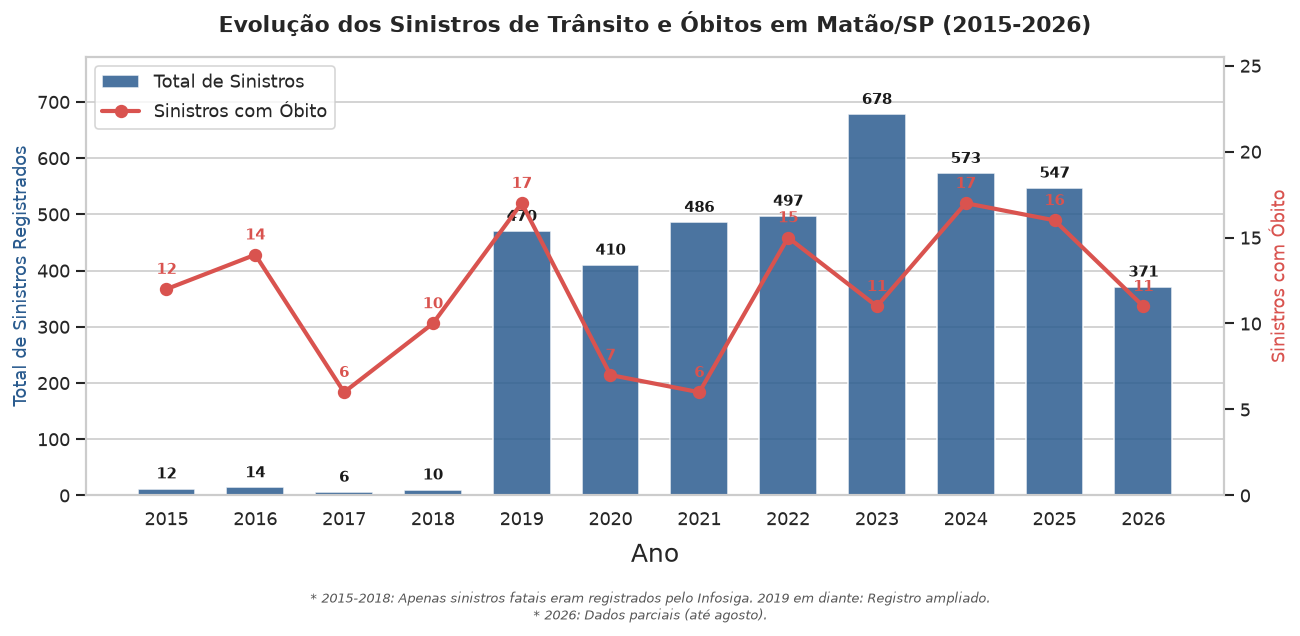

,ano,total_sinistros,sinistros_fatais
0,2015,12,12
1,2016,14,14
2,2017,6,6
3,2018,10,10
4,2019,470,17
5,2020,410,7
6,2021,486,6
7,2022,497,15
8,2023,678,11
9,2024,573,17


In [12]:
# 5.1 (A): Evolução Anual dos Sinistros e Fatalidades (2015 a 2026)

# Agrupando os dados por ano: Total de Sinistros e Total de Fatais
dados_ano = df.groupby('ano').agg(
    total_sinistros=('id_sinistro', 'count'),
    sinistros_fatais=('mortos', lambda x: (x > 0).sum())
).reset_index()

fig, ax1 = plt.subplots(figsize=(11, 5))

# Cores
cor_barras = '#2b5c8f'
cor_linha = '#d9534f'

# 1. Gráfico de Barras: Total de Sinistros
barras = ax1.bar(
    dados_ano['ano'], 
    dados_ano['total_sinistros'], 
    color=cor_barras, 
    alpha=0.85, 
    label='Total de Sinistros', 
    width=0.65
)

# Adicionar rótulos numéricos no topo de cada barra
for barra in barras:
    altura = barra.get_height()
    ax1.annotate(
        f'{int(altura)}',
        xy=(barra.get_x() + barra.get_width() / 2, altura),
        xytext=(0, 4),
        textcoords="offset points",
        ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1a1a1a'
    )

# 2. Linha com Marcadores: Sinistros com Vítimas Fatais
ax2 = ax1.twinx()  # Eixo secundário à direita
linha = ax2.plot(
    dados_ano['ano'], 
    dados_ano['sinistros_fatais'], 
    color=cor_linha, 
    marker='o', 
    linewidth=2.5, 
    markersize=7, 
    label='Sinistros com Óbito'
)

# Rótulos na linha de óbitos
for x, y in zip(dados_ano['ano'], dados_ano['sinistros_fatais']):
    ax2.annotate(
        f'{int(y)}',
        xy=(x, y),
        xytext=(0, 7),
        textcoords="offset points",
        ha='center', va='bottom', fontsize=9, fontweight='bold', color=cor_linha
    )

# Configurações dos eixos e títulos
ax1.set_title('Evolução dos Sinistros de Trânsito e Óbitos em Matão/SP (2015-2026)', fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Ano', fontsize=15, labelpad=8)
ax1.set_ylabel('Total de Sinistros Registrados', fontsize=11, color=cor_barras)
ax2.set_ylabel('Sinistros com Óbito', fontsize=11, color=cor_linha)

# Ajustes de limites e ticks
ax1.set_xticks(dados_ano['ano'])
ax1.set_ylim(0, dados_ano['total_sinistros'].max() * 1.15)
ax2.set_ylim(0, dados_ano['sinistros_fatais'].max() * 1.5)
ax1.grid(axis='x')
ax2.grid(False)  # Evitar sobreposição de grades

# Legenda combinada
linhas, rotulos = ax1.get_legend_handles_labels()
linhas2, rotulos2 = ax2.get_legend_handles_labels()
ax1.legend(linhas + linhas2, rotulos + rotulos2, loc='upper left', frameon=True)

# Nota explicativa metodológica no rodapé do gráfico
plt.figtext(
    0.5, -0.05, 
    "* 2015-2018: Apenas sinistros fatais eram registrados pelo Infosiga. 2019 em diante: Registro ampliado.\n* 2026: Dados parciais (até agosto).", 
    ha="center", fontsize=8, style='italic', color='#555555'
)

plt.tight_layout()
plt.savefig('../output/graficos/acidentes_por_ano.png', dpi=200, bbox_inches='tight')
plt.show()

# Resumo numérico complementar
dados_ano


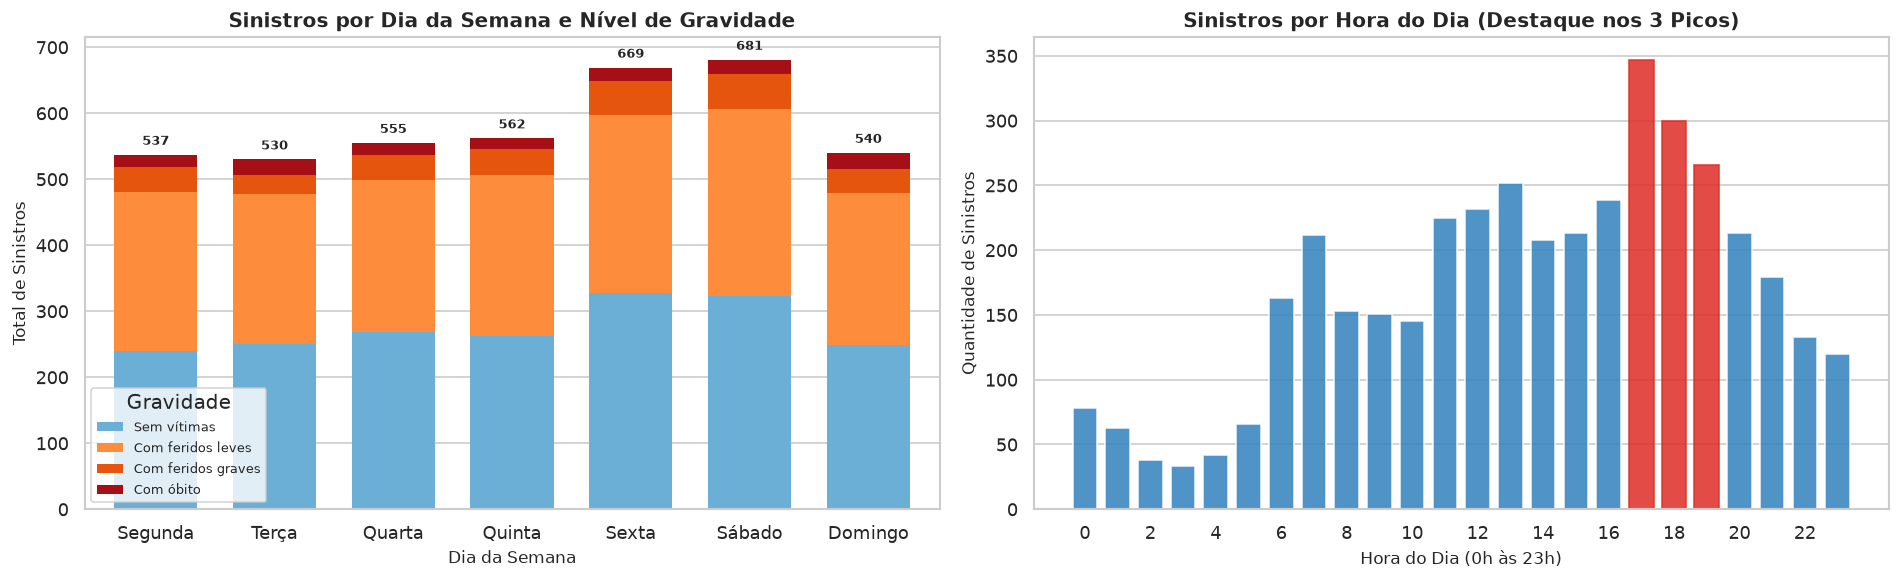

--- Top 5 Horários Mais Perigosos em Matão ---
 -> 17:00h: 347 acidentes
 -> 18:00h: 300 acidentes
 -> 19:00h: 266 acidentes
 -> 13:00h: 252 acidentes
 -> 16:00h: 239 acidentes


In [13]:
# 5.1 (B): Padrões de Dia da Semana e Horário do Dia

# 1. Definir a ordem cronológica correta dos dias da semana
dias_ordenados = [
    'Segunda-feira', 'Terça-feira', 'Quarta-feira', 
    'Quinta-feira', 'Sexta-feira', 'Sábado', 'Domingo'
]

# --- GRÁFICO 1: Acidentes por Dia da Semana e Gravidade ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Tabela cruzada: Dia da semana x Gravidade
ordem_gravidade = ['Sem vítimas', 'Com feridos leves', 'Com feridos graves', 'Com óbito']
crosstab_dias = pd.crosstab(df['dia_semana'], df['gravidade']).reindex(index=dias_ordenados, columns=ordem_gravidade)

# Cores para gravidade: azul (sem vítima), amarelo (leves), laranja (graves), vermelho (óbitos)
paleta_gravidade = ['#6baed6', '#fd8d3c', '#e6550d', '#a50f15']

crosstab_dias.plot(
    kind='bar', 
    stacked=True, 
    ax=axes[0], 
    color=paleta_gravidade, 
    edgecolor='none', 
    width=0.7
)

axes[0].set_title('Sinistros por Dia da Semana e Nível de Gravidade', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Dia da Semana', fontsize=10)
axes[0].set_ylabel('Total de Sinistros', fontsize=10)
axes[0].set_xticklabels([d.replace('-feira', '') for d in dias_ordenados], rotation=0)
axes[0].legend(title='Gravidade', frameon=True, fontsize=8)
axes[0].grid(axis='x')

# Adicionar total geral acima de cada barra do dia
totais_dias = crosstab_dias.sum(axis=1)
for i, total in enumerate(totais_dias):
    axes[0].annotate(
        f'{total}', 
        xy=(i, total), 
        xytext=(0, 4), 
        textcoords="offset points", 
        ha='center', va='bottom', fontsize=8, fontweight='bold'
    )


# --- GRÁFICO 2: Distribuição por Hora do Dia ---
df_hora_valida = df.dropna(subset=['hora_int']).copy()
contagem_horas = df_hora_valida['hora_int'].value_counts().reindex(range(24), fill_value=0)

barras_hora = axes[1].bar(
    contagem_horas.index, 
    contagem_horas.values, 
    color='#3182bd', 
    alpha=0.85, 
    width=0.75
)

# Destacar os 3 horários de pico com cor diferente (vermelho escuro)
top_3_horas = contagem_horas.nlargest(3).index
for hora, barra in zip(contagem_horas.index, barras_hora):
    if hora in top_3_horas:
        barra.set_color('#de2d26')

axes[1].set_title('Sinistros por Hora do Dia (Destaque nos 3 Picos)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hora do Dia (0h às 23h)', fontsize=10)
axes[1].set_ylabel('Quantidade de Sinistros', fontsize=10)
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(axis='x')

plt.tight_layout()
plt.savefig('../output/graficos/acidentes_dia_e_hora.png', dpi=150, bbox_inches='tight')
plt.show()

# Exibir os 3 horários com maior volume
print("--- Top 5 Horários Mais Perigosos em Matão ---")
for h, qtd in contagem_horas.nlargest(5).items():
    print(f" -> {int(h):02d}:00h: {qtd} acidentes")


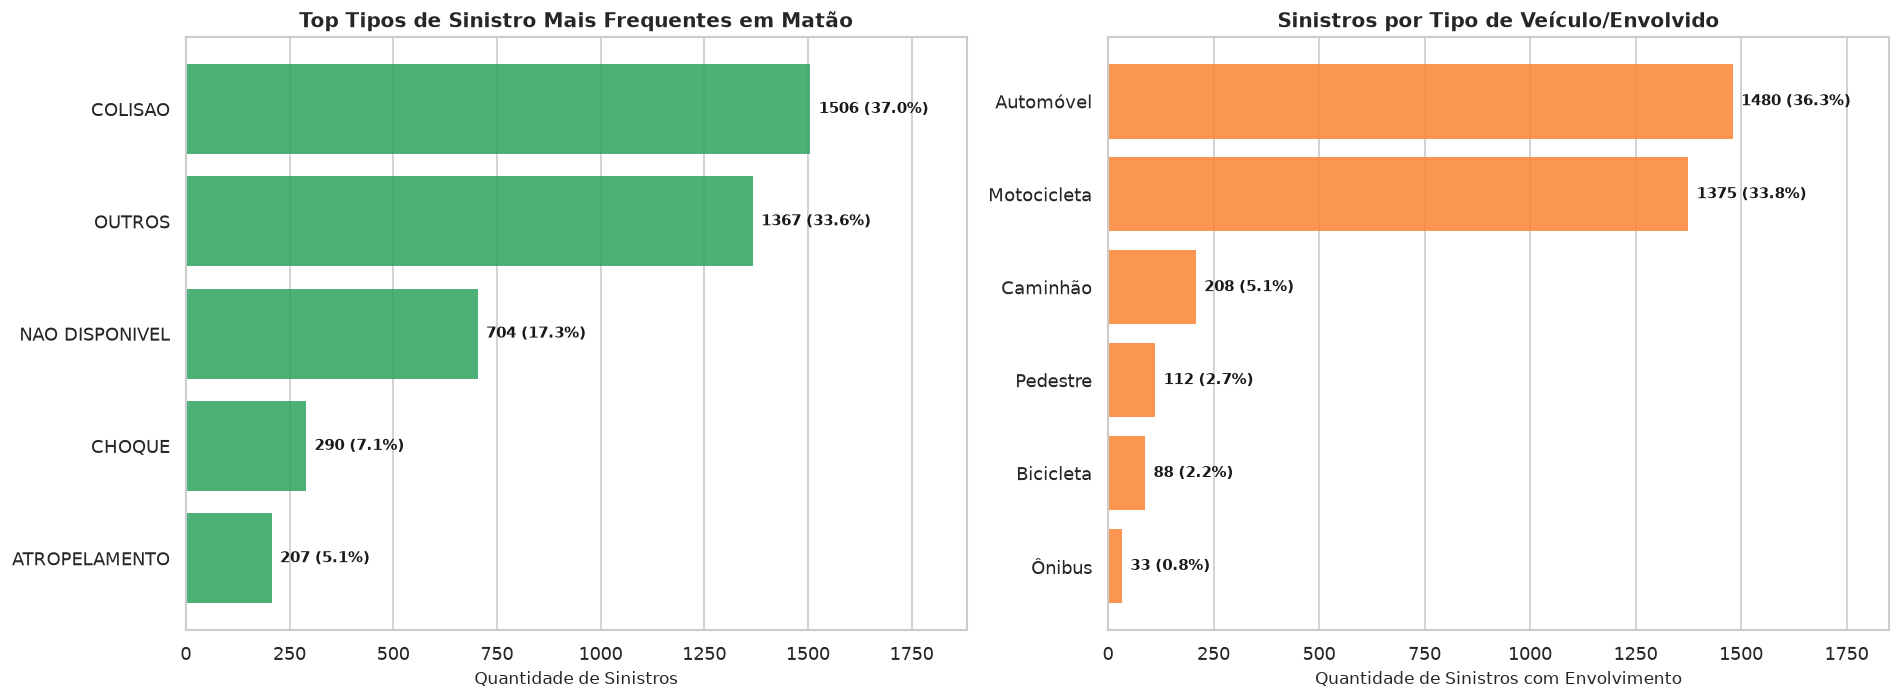

--- Envolvimento por Modal em Matão ---
 -> Automóvel: presente em 1480 acidentes (36.3%)
 -> Motocicleta: presente em 1375 acidentes (33.8%)
 -> Caminhão: presente em 208 acidentes (5.1%)
 -> Pedestre: presente em 112 acidentes (2.7%)
 -> Bicicleta: presente em 88 acidentes (2.2%)
 -> Ônibus: presente em 33 acidentes (0.8%)


In [14]:
# 5.2: Tipos de Sinistros e Modais Mais Envolvidos

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: Tipos de Sinistros Mais Frequentes ---
contagem_tipos = df['tipo_sinistro'].value_counts()
top_tipos = contagem_tipos.head(8).sort_values(ascending=True)

barras_tipos = axes[0].barh(
    top_tipos.index, 
    top_tipos.values, 
    color='#2ca25f', 
    alpha=0.85, 
    edgecolor='none'
)

# Adicionar rótulos de contagem e percentual em cada barra horizontal
total_sinistros = len(df)
for barra in barras_tipos:
    largura = barra.get_width()
    pct = (largura / total_sinistros) * 100
    axes[0].annotate(
        f'{int(largura)} ({pct:.1f}%)', 
        xy=(largura, barra.get_y() + barra.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha='left', va='center', fontsize=9, fontweight='bold', color='#1a1a1a'
    )

axes[0].set_title('Top Tipos de Sinistro Mais Frequentes em Matão', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Quantidade de Sinistros', fontsize=10)
axes[0].set_xlim(0, top_tipos.max() * 1.25)
axes[0].grid(axis='y')


# --- GRÁFICO 2: Presença dos Modais nos Sinistros ---
# Contamos em quantos acidentes houve pelo menos 1 veículo/pedestre daquela categoria
modais = {
    'Automóvel': (df['qtd_automovel'] > 0).sum(),
    'Motocicleta': (df['qtd_motocicleta'] > 0).sum(),
    'Caminhão': (df['qtd_caminhao'] > 0).sum(),
    'Pedestre': (df['qtd_pedestre'] > 0).sum(),
    'Bicicleta': (df['qtd_bicicleta'] > 0).sum(),
    'Ônibus': (df['qtd_onibus'] > 0).sum()
}
serie_modais = pd.Series(modais).sort_values(ascending=True)

barras_modais = axes[1].barh(
    serie_modais.index, 
    serie_modais.values, 
    color='#fa8431', 
    alpha=0.85, 
    edgecolor='none'
)

for barra in barras_modais:
    largura = barra.get_width()
    pct = (largura / total_sinistros) * 100
    axes[1].annotate(
        f'{int(largura)} ({pct:.1f}%)', 
        xy=(largura, barra.get_y() + barra.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha='left', va='center', fontsize=9, fontweight='bold', color='#1a1a1a'
    )

axes[1].set_title('Sinistros por Tipo de Veículo/Envolvido', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Quantidade de Sinistros com Envolvimento', fontsize=10)
axes[1].set_xlim(0, serie_modais.max() * 1.25)
axes[1].grid(axis='y')

plt.tight_layout()
plt.savefig('../output/graficos/tipos_e_veiculos.png', dpi=150, bbox_inches='tight')
plt.show()

# Resumo numérico do ranking dos modais
print("--- Envolvimento por Modal em Matão ---")
for modal, qtd in serie_modais.sort_values(ascending=False).items():
    print(f" -> {modal}: presente em {qtd} acidentes ({(qtd/total_sinistros)*100:.1f}%)")


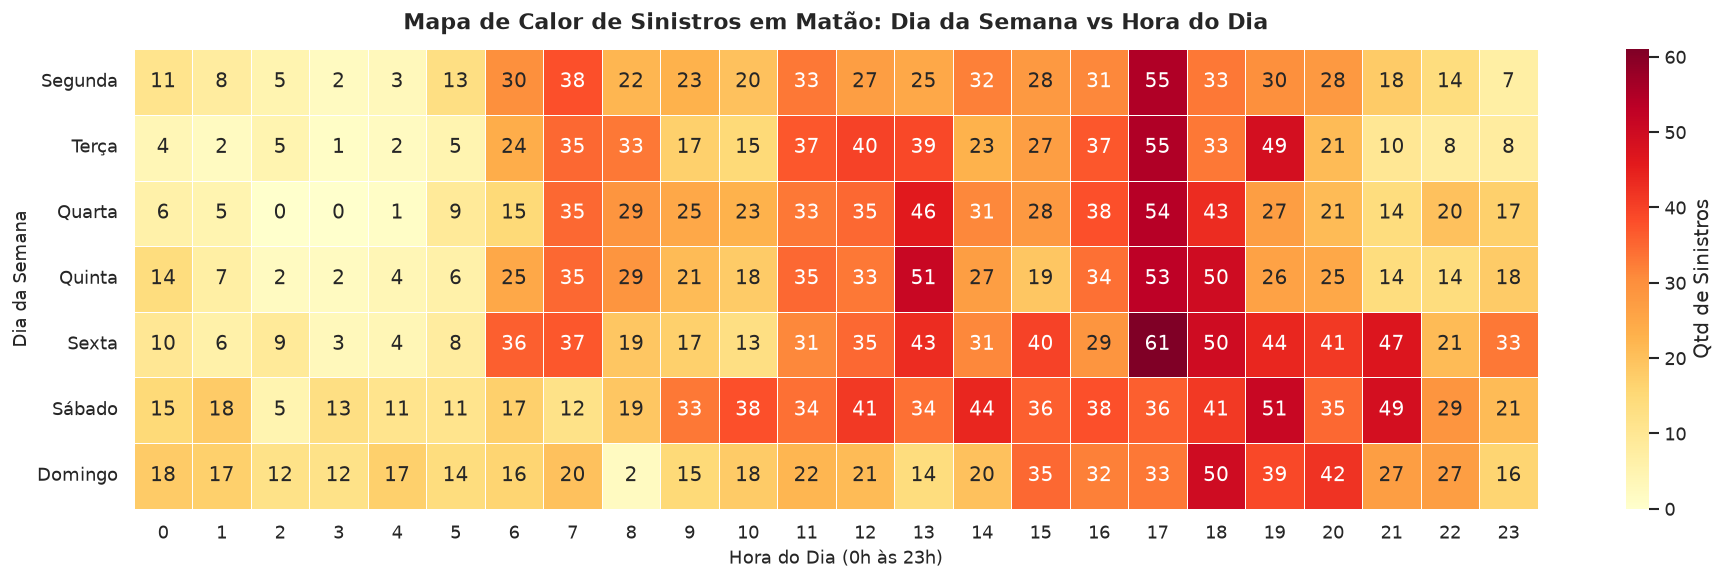

--- Tabela: Tipo de Sinistro vs Gravidade e Letalidade ---


gravidade,Sem vítimas,Com feridos leves,Com feridos graves,Com óbito,Total,Taxa_Letalidade_%
tipo_sinistro,,,,,,
CHOQUE,23,192,34,41,290,14.14
ATROPELAMENTO,91,74,26,16,207,7.73
COLISAO,174,1098,176,58,1506,3.85
OUTROS,1004,294,45,24,1367,1.76
NAO DISPONIVEL,628,68,5,3,704,0.43


In [15]:
# 5.3: Cruzamento de Variáveis - Heatmap Dia x Hora e Matriz de Gravidade

dias_ordenados = [
    'Segunda-feira', 'Terça-feira', 'Quarta-feira', 
    'Quinta-feira', 'Sexta-feira', 'Sábado', 'Domingo'
]

# --- 1. HEATMAP: Dia da Semana vs Hora do Dia ---
df_hora_valida = df.dropna(subset=['hora_int']).copy()
df_hora_valida['hora_int'] = df_hora_valida['hora_int'].astype(int)

heatmap_dia_hora = df_hora_valida.pivot_table(
    index='dia_semana', 
    columns='hora_int', 
    values='id_sinistro', 
    aggfunc='count', 
    fill_value=0
).reindex(dias_ordenados)

plt.figure(figsize=(16, 5))
sns.heatmap(
    heatmap_dia_hora, 
    cmap='YlOrRd', 
    linewidths=0.5, 
    annot=True, 
    fmt='d', 
    cbar_kws={'label': 'Qtd de Sinistros'}
)
plt.title('Mapa de Calor de Sinistros em Matão: Dia da Semana vs Hora do Dia', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Hora do Dia (0h às 23h)', fontsize=11)
plt.ylabel('Dia da Semana', fontsize=11)
plt.yticks([i + 0.5 for i in range(7)], [d.replace('-feira', '') for d in dias_ordenados], rotation=0)

plt.tight_layout()
plt.savefig('../output/graficos/heatmap_dia_hora.png', dpi=150, bbox_inches='tight')
plt.show()


# --- 2. CRUZAMENTO: Tipo de Sinistro vs Gravidade e Letalidade ---
# Pegando os tipos com pelo menos 30 ocorrências para evitar distorção estatística
tipos_relevantes = df['tipo_sinistro'].value_counts()[lambda x: x >= 30].index

crosstab_tipo_grav = pd.crosstab(
    df[df['tipo_sinistro'].isin(tipos_relevantes)]['tipo_sinistro'], 
    df['gravidade']
)[['Sem vítimas', 'Com feridos leves', 'Com feridos graves', 'Com óbito']]

# Adicionar Total e Taxa de Letalidade (% de óbitos)
crosstab_tipo_grav['Total'] = crosstab_tipo_grav.sum(axis=1)
crosstab_tipo_grav['Taxa_Letalidade_%'] = ((crosstab_tipo_grav['Com óbito'] / crosstab_tipo_grav['Total']) * 100).round(2)
crosstab_tipo_grav = crosstab_tipo_grav.sort_values(by='Taxa_Letalidade_%', ascending=False)

print("--- Tabela: Tipo de Sinistro vs Gravidade e Letalidade ---")
crosstab_tipo_grav


In [17]:
# 7.1: Teste de Hipótese Estatística - Dias Úteis vs Finais de Semana
from scipy import stats

# Filtramos de 2019 em diante (período com coleta completa de todos os sinistros)
df_recente = df[df['ano'] >= 2019].copy()

# 1. Agrupar sinistros por dia corrido (data) e marcar se é fim de semana
sinistros_diarios = df_recente.groupby(['data', 'fim_de_semana']).size().reset_index(name='qtd_acidentes')

uteis = sinistros_diarios[sinistros_diarios['fim_de_semana'] == False]['qtd_acidentes']
fds = sinistros_diarios[sinistros_diarios['fim_de_semana'] == True]['qtd_acidentes']

# 2. Estatísticas descritivas
print("--- Médias Diárias de Sinistros (2019-2026) ---")
print(f"Média em Dias Úteis:      {uteis.mean():.2f} acidentes/dia (Desvio Padrão: {uteis.std():.2f})")
print(f"Média em Fins de Semana:  {fds.mean():.2f} acidentes/dia (Desvio Padrão: {fds.std():.2f})")

# 3. Teste t de Student (Welch)
t_stat, p_value = stats.ttest_ind(uteis, fds, equal_var=False)

print("\n--- Resultado do Teste de Hipótese ---")
print(f"Estatística t: {t_stat:.4f}")
print(f"p-valor:       {p_value:.4e}")

if p_value < 0.05:
    print("\n Conclusão: Há diferença estatisticamente significativa (p < 0.05).")
    if uteis.mean() > fds.mean():
        print("Dias úteis registram significativamente mais sinistros que fins de semana.")
    else:
        print("Fins de semana registram significativamente mais sinistros que dias úteis.")
else:
    print("\n Conclusão: Não há evidência estatística de diferença significativa entre os dois períodos.")


--- Médias Diárias de Sinistros (2019-2026) ---
Média em Dias Úteis:      2.03 acidentes/dia (Desvio Padrão: 1.23)
Média em Fins de Semana:  2.04 acidentes/dia (Desvio Padrão: 1.21)

--- Resultado do Teste de Hipótese ---
Estatística t: -0.3053
p-valor:       7.6018e-01

 Conclusão: Não há evidência estatística de diferença significativa entre os dois períodos.


Dados de Treino: 2849 amostras
Dados de Teste:  1222 amostras

--- Relatório de Classificação (Conjunto de Teste) ---
                    precision    recall  f1-score   support

Com feridos graves       0.12      0.16      0.14        86
 Com feridos leves       0.80      0.74      0.77       518
         Com óbito       0.26      0.36      0.30        42
       Sem vítimas       0.98      0.97      0.97       576

          accuracy                           0.79      1222
         macro avg       0.54      0.56      0.54      1222
      weighted avg       0.82      0.79      0.80      1222



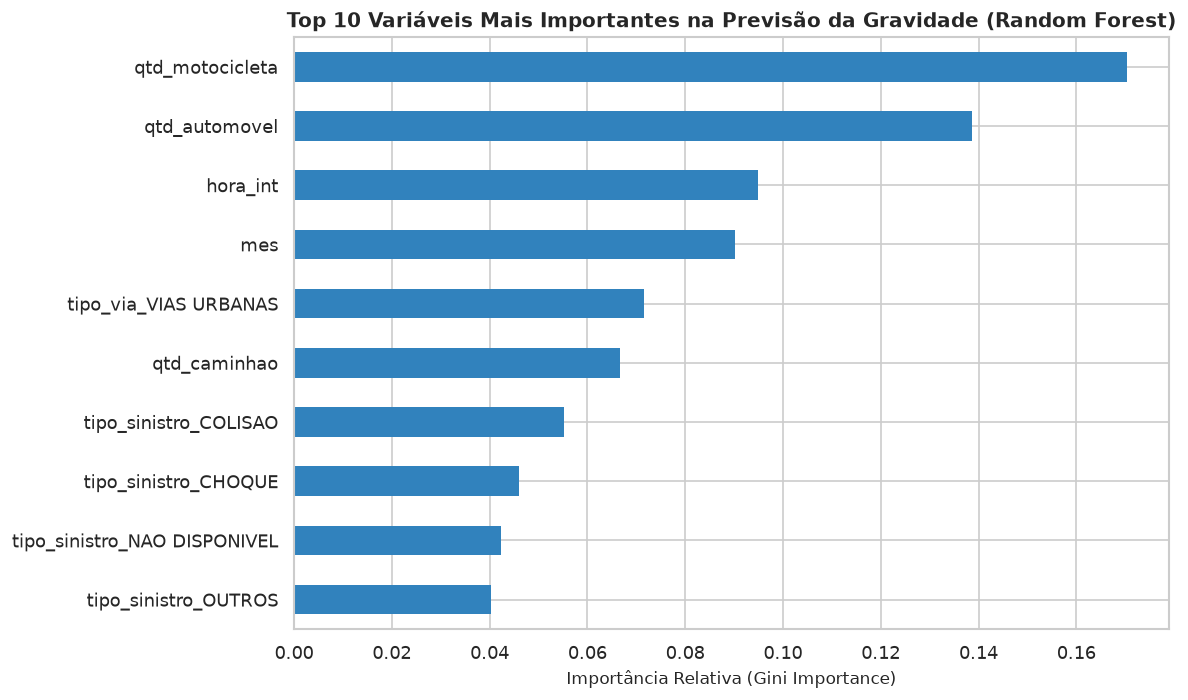

In [18]:
# 7.2: Modelo Preditivo de Machine Learning (Random Forest Classifier)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Seleção das Features (variáveis preditoras) e Target (alvo)
features_categoricas = ['tipo_sinistro', 'tipo_via', 'dia_semana', 'turno']
features_numericas = [
    'hora_int', 'mes', 'qtd_motocicleta', 
    'qtd_automovel', 'qtd_caminhao', 'qtd_pedestre', 'qtd_bicicleta'
]

# Filtrar registros sem valores nulos nas features
df_ml = df[features_categoricas + features_numericas + ['gravidade']].dropna().copy()

# 2. Pré-processamento: One-Hot Encoding nas variáveis categóricas
X = pd.get_dummies(df_ml[features_categoricas + features_numericas], columns=features_categoricas, drop_first=True)
y = df_ml['gravidade']

# 3. Divisão Treino e Teste (70% treino, 30% teste) com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y
)

print(f"Dados de Treino: {X_train.shape[0]} amostras")
print(f"Dados de Teste:  {X_test.shape[0]} amostras")

# 4. Treinamento com RandomForest e balanceamento de pesos
clf = RandomForestClassifier(
    n_estimators=150, 
    max_depth=10, 
    class_weight='balanced', 
    random_state=42
)
clf.fit(X_train, y_train)

# 5. Avaliação do Modelo no Conjunto de Teste
y_pred = clf.predict(X_test)

print("\n--- Relatório de Classificação (Conjunto de Teste) ---")
print(classification_report(y_test, y_pred, zero_division=0))

# 6. Gráfico das 10 Variáveis Mais Importantes para o Modelo
importancias = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importancias.tail(10).plot(kind='barh', color='#3182bd', edgecolor='none')
plt.title('Top 10 Variáveis Mais Importantes na Previsão da Gravidade (Random Forest)', fontsize=12, fontweight='bold')
plt.xlabel('Importância Relativa (Gini Importance)', fontsize=10)
plt.tight_layout()
plt.savefig('../output/graficos/importancia_features_ml.png', dpi=150, bbox_inches='tight')
plt.show()
